# Detecção de Outliers em Séries Temporais Financeiras

**Autor:** Renan Santos Mendes

**Email:** renansantosmendes@gmail.com

**Disciplina:** Projeto em Deep Learning

**Curso:** Ciência de Dados e IA

---

Este notebook compara duas abordagens de detecção de outliers em uma
série temporal financeira real, obtida com a biblioteca `yfinance`.
São comparadas as seguintes abordagens:

- Método estatístico baseado na distância de Mahalanobis.
- Autoencoder implementado manualmente com `PyTorch`.

Como referência adicional (não como gabarito), também é calculado um
indicador simples baseado em z-score dos retornos diários.

## Importação das bibliotecas

A célula a seguir importa todas as bibliotecas utilizadas ao longo do
notebook e fixa as sementes de aleatoriedade, garantindo a
reprodutibilidade dos resultados.

In [20]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import yfinance as yf

from generative_models.tracking.wandb_tracker import WandbExperimentTracker

torch.manual_seed(42)
np.random.seed(42)

## Carregamento da série financeira

A função `fetch_price_series` faz o download dos preços de fechamento
ajustados de um ativo financeiro utilizando o `yfinance`, para o
intervalo de datas informado.

In [21]:
def fetch_price_series(
    ticker: str,
    start_date: str,
    end_date: str,
) -> pd.Series:
    """Download the adjusted close price series for a given ticker.

    Args:
        ticker: The stock or asset ticker symbol (e.g. "AAPL").
        start_date: The start date of the period, in "YYYY-MM-DD"
            format.
        end_date: The end date of the period, in "YYYY-MM-DD" format.

    Returns:
        A pandas Series containing the adjusted close price indexed
        by date, with missing values removed.
    """
    data = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        auto_adjust=True,
    )
    data = data.dropna()
    return data["Close"].squeeze()

A célula abaixo define os parâmetros do ativo a ser analisado e
executa o download da série de preços.

In [22]:
TICKER = "AAPL"
START_DATE = "2020-01-01"
END_DATE = "2026-01-01"

price = fetch_price_series(TICKER, START_DATE, END_DATE)

[*********************100%***********************]  1 of 1 completed


## Construção do dataframe de retornos

A função `build_return_dataframe` calcula os log-retornos diários a
partir da série de preços e organiza os dados em um `DataFrame` com as
colunas de data, retorno e preço.

In [23]:
def build_return_dataframe(price_series: pd.Series) -> pd.DataFrame:
    """Build a dataframe of log returns from a price series.

    Args:
        price_series: A pandas Series of asset prices indexed by
            date.

    Returns:
        A DataFrame with the columns "date", "return" and "price",
        where "return" contains the daily log returns and "price"
        contains the price aligned with each return.
    """
    log_returns = np.log(price_series).diff().dropna()
    return pd.DataFrame(
        {
            "date": log_returns.index,
            "return": log_returns.values,
            "price": price_series.loc[log_returns.index].values,
        }
    ).reset_index(drop=True)

In [24]:
df = build_return_dataframe(price)
number_of_observations = len(df)

print(
    f"Ticker: {TICKER} | Observacoes: {number_of_observations} | "
    f"Periodo: {df['date'].min().date()} a {df['date'].max().date()}"
)

Ticker: AAPL | Observacoes: 1507 | Periodo: 2020-01-03 a 2025-12-31


## Construção das janelas deslizantes

Os autoencoders recebem como entrada janelas deslizantes dos retornos
diários. A função `create_sliding_windows` transforma a série de
retornos em uma matriz de janelas de tamanho fixo.

In [25]:
def create_sliding_windows(
    series: np.ndarray,
    window_size: int,
) -> np.ndarray:
    """Create sliding windows over a one-dimensional array.

    Args:
        series: A one-dimensional array containing the values to be
            windowed.
        window_size: The number of consecutive values in each
            window.

    Returns:
        A two-dimensional array of shape
        (len(series) - window_size + 1, window_size), where each row
        is a consecutive slice of the input series.

    Example:
        >>> create_sliding_windows(np.array([1, 2, 3, 4]), 2)
        array([[1, 2],
               [2, 3],
               [3, 4]])
    """
    number_of_windows = len(series) - window_size + 1
    return np.array(
        [series[index:index + window_size] for index in range(number_of_windows)]
    )

In [26]:
WINDOW_SIZE = 10
CONTAMINATION = 0.02

raw_windows = create_sliding_windows(df["return"].values, WINDOW_SIZE)

windows_mean = raw_windows.mean()
windows_std = raw_windows.std()
normalized_windows = (raw_windows - windows_mean) / windows_std

windows_tensor = torch.tensor(normalized_windows, dtype=torch.float32)

## Método estatístico: distância de Mahalanobis

Nesta etapa, um método puramente estatístico é aplicado às janelas
normalizadas dos retornos: a distância de Mahalanobis de cada janela
até o vetor médio das janelas, considerando a matriz de covariância
entre as posições da janela. Diferentemente do autoencoder, esse
método não requer treinamento, apenas o cálculo da média e da
covariância amostral das janelas.

In [27]:
def compute_mahalanobis_scores(
    windows: np.ndarray,
) -> np.ndarray:
    """Compute the Mahalanobis distance of each window to the mean.

    Args:
        windows: A two-dimensional array of shape
            (num_windows, window_size) containing the (normalized)
            sliding windows.

    Returns:
        A one-dimensional array with the Mahalanobis distance of
        each window to the sample mean vector, computed from the
        (regularized) sample covariance matrix of the windows.
    """
    mean_vector = windows.mean(axis=0)
    covariance_matrix = np.cov(windows, rowvar=False)
    covariance_matrix += np.eye(covariance_matrix.shape[0]) * 1e-6
    inverse_covariance = np.linalg.inv(covariance_matrix)

    centered_windows = windows - mean_vector
    squared_distances = np.einsum(
        "ij,jk,ik->i",
        centered_windows,
        inverse_covariance,
        centered_windows,
    )
    return np.sqrt(squared_distances)


stat_scores = compute_mahalanobis_scores(normalized_windows)

stat_threshold = np.percentile(stat_scores, 100 * (1 - CONTAMINATION))
stat_labels = (stat_scores > stat_threshold).astype(int)

## Autoencoder manual com PyTorch

A classe `SimpleAutoencoder` implementa um autoencoder simples,
composto por um codificador e um decodificador com camadas lineares e
ativação `ReLU`.

In [28]:
class SimpleAutoencoder(nn.Module):
    """A simple fully connected autoencoder.

    The network is composed of an encoder that compresses the input
    into a lower-dimensional latent representation, and a decoder
    that reconstructs the original input from that representation.

    Attributes:
        encoder: The sequential module that encodes the input into
            the latent space.
        decoder: The sequential module that reconstructs the input
            from the latent space.
    """

    def __init__(
        self,
        input_dim: int,
        hidden_dim: int = 16,
        latent_dim: int = 4,
    ) -> None:
        """Initialize the encoder and decoder layers.

        Args:
            input_dim: The dimensionality of the input features.
            hidden_dim: The number of units in the hidden layers.
            latent_dim: The dimensionality of the latent
                representation.
        """
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, input_tensor: torch.Tensor) -> torch.Tensor:
        """Run the forward pass through the autoencoder.

        Args:
            input_tensor: A tensor of shape (batch_size, input_dim)
                containing the input features.

        Returns:
            A tensor of shape (batch_size, input_dim) containing the
            reconstructed input.
        """
        latent_representation = self.encoder(input_tensor)
        return self.decoder(latent_representation)

A função `train_autoencoder` executa o laço de treinamento do
autoencoder em PyTorch, utilizando o otimizador `Adam` e o erro
quadrático médio como função de perda.

In [29]:
def train_autoencoder(
    model: nn.Module,
    input_tensor: torch.Tensor,
    num_epochs: int,
    learning_rate: float,
    experiment_tracker: WandbExperimentTracker | None = None,
) -> nn.Module:
    """Train an autoencoder using mean squared error reconstruction loss.

    Args:
        model: The autoencoder model to be trained.
        input_tensor: A tensor containing the training data, where
            each row is an input sample.
        num_epochs: The number of training epochs.
        learning_rate: The learning rate used by the Adam optimizer.
        experiment_tracker: Optional tracker used to log the
            per-epoch training loss to Weights & Biases. When `None`,
            no logging is performed.

    Returns:
        The trained autoencoder model.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss(reduction="none")

    model.train()
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        reconstruction = model(input_tensor)
        loss = criterion(reconstruction, input_tensor).mean()
        loss.backward()
        optimizer.step()

        if experiment_tracker is not None:
            experiment_tracker.log_metrics(
                {"epoch": epoch + 1, "train/loss_mse": loss.item()}
            )

        if (epoch + 1) % 30 == 0:
            print(f"[PyTorch AE] Epoch {epoch + 1}/{num_epochs} - loss: {loss.item():.5f}")

    return model

A função `compute_reconstruction_scores` calcula, para cada amostra,
o erro médio de reconstrução do autoencoder já treinado, que é
utilizado como escore de anomalia.

In [30]:
def compute_reconstruction_scores(
    model: nn.Module,
    input_tensor: torch.Tensor,
) -> np.ndarray:
    """Compute per-sample reconstruction error scores.

    Args:
        model: A trained autoencoder model.
        input_tensor: A tensor containing the samples to be scored.

    Returns:
        A one-dimensional numpy array with the mean squared
        reconstruction error for each sample.
    """
    criterion = nn.MSELoss(reduction="none")
    model.eval()
    with torch.no_grad():
        reconstruction = model(input_tensor)
        errors = criterion(reconstruction, input_tensor).mean(dim=1)
    return errors.cpu().numpy()

`WandbExperimentTracker` centraliza a tentativa de login, a
inicialização do run e o registro de métricas no Weights & Biases. A
`WANDB_API_KEY` é lida de um arquivo `.env` local; se nenhuma chave
for encontrada, um run anônimo é iniciado. O laço de treinamento do
autoencoder registra a loss de reconstrução a cada época.

In [31]:
NUM_EPOCHS = 300
LEARNING_RATE = 1e-3

experiment_tracker = WandbExperimentTracker(
    project_name="outlier-detection-comparison",
    config={
        "ticker": TICKER,
        "start_date": START_DATE,
        "end_date": END_DATE,
        "window_size": WINDOW_SIZE,
        "contamination": CONTAMINATION,
        "epochs": NUM_EPOCHS,
        "learning_rate": LEARNING_RATE,
        "optimizer": "Adam",
        "loss_function": "MSE",
        "model": "SimpleAutoencoder",
    },
)
experiment_tracker.start_run()

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\renan\_netrc
wandb: Currently logged in as: renansantosmendes to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


[wandb] Run started in 'online' mode (project='outlier-detection-comparison').


In [32]:
device = "cuda" if torch.cuda.is_available() else "cpu"
windows_tensor = windows_tensor.to(device)

torch_model = SimpleAutoencoder(input_dim=WINDOW_SIZE).to(device)
torch_model = train_autoencoder(
    torch_model,
    windows_tensor,
    num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    experiment_tracker=experiment_tracker,
)

torch_scores = compute_reconstruction_scores(torch_model, windows_tensor)

anomaly_threshold = np.percentile(torch_scores, 100 * (1 - CONTAMINATION))
torch_labels = (torch_scores > anomaly_threshold).astype(int)

epoch: 1 | train/loss_mse: 1.040855
epoch: 2 | train/loss_mse: 1.038890
epoch: 3 | train/loss_mse: 1.036972
epoch: 4 | train/loss_mse: 1.035098
epoch: 5 | train/loss_mse: 1.033264
epoch: 6 | train/loss_mse: 1.031460
epoch: 7 | train/loss_mse: 1.029698
epoch: 8 | train/loss_mse: 1.027971
epoch: 9 | train/loss_mse: 1.026284
epoch: 10 | train/loss_mse: 1.024628
epoch: 11 | train/loss_mse: 1.023002
epoch: 12 | train/loss_mse: 1.021402
epoch: 13 | train/loss_mse: 1.019830
epoch: 14 | train/loss_mse: 1.018285
epoch: 15 | train/loss_mse: 1.016759
epoch: 16 | train/loss_mse: 1.015253
epoch: 17 | train/loss_mse: 1.013780
epoch: 18 | train/loss_mse: 1.012344
epoch: 19 | train/loss_mse: 1.010932
epoch: 20 | train/loss_mse: 1.009527
epoch: 21 | train/loss_mse: 1.008131
epoch: 22 | train/loss_mse: 1.006738
epoch: 23 | train/loss_mse: 1.005356
epoch: 24 | train/loss_mse: 1.003978
epoch: 25 | train/loss_mse: 1.002609
epoch: 26 | train/loss_mse: 1.001238
epoch: 27 | train/loss_mse: 0.999866
epoch: 28 

## Alinhamento dos índices

Como cada janela termina em uma posição diferente da série original,
é necessário mapear os rótulos das janelas de volta para os índices
correspondentes no `DataFrame` de retornos.

In [33]:
window_end_indices = np.arange(WINDOW_SIZE - 1, number_of_observations)

## Referência simples baseada em z-score

Como referência adicional, e não como gabarito, calcula-se o z-score
dos retornos diários. Retornos com `|z-score| > 3` são tratados como
choques relevantes na série.

In [34]:
z_scores = (df["return"] - df["return"].mean()) / df["return"].std()
zscore_outlier_indices = df.index[np.abs(z_scores) > 3].values

## Comparação visual entre os métodos

Os gráficos a seguir apresentam, sobre a série de preços, os pontos
identificados como anomalias pela referência de z-score, pelo método
estatístico da distância de Mahalanobis e pelo autoencoder manual em
`PyTorch`.

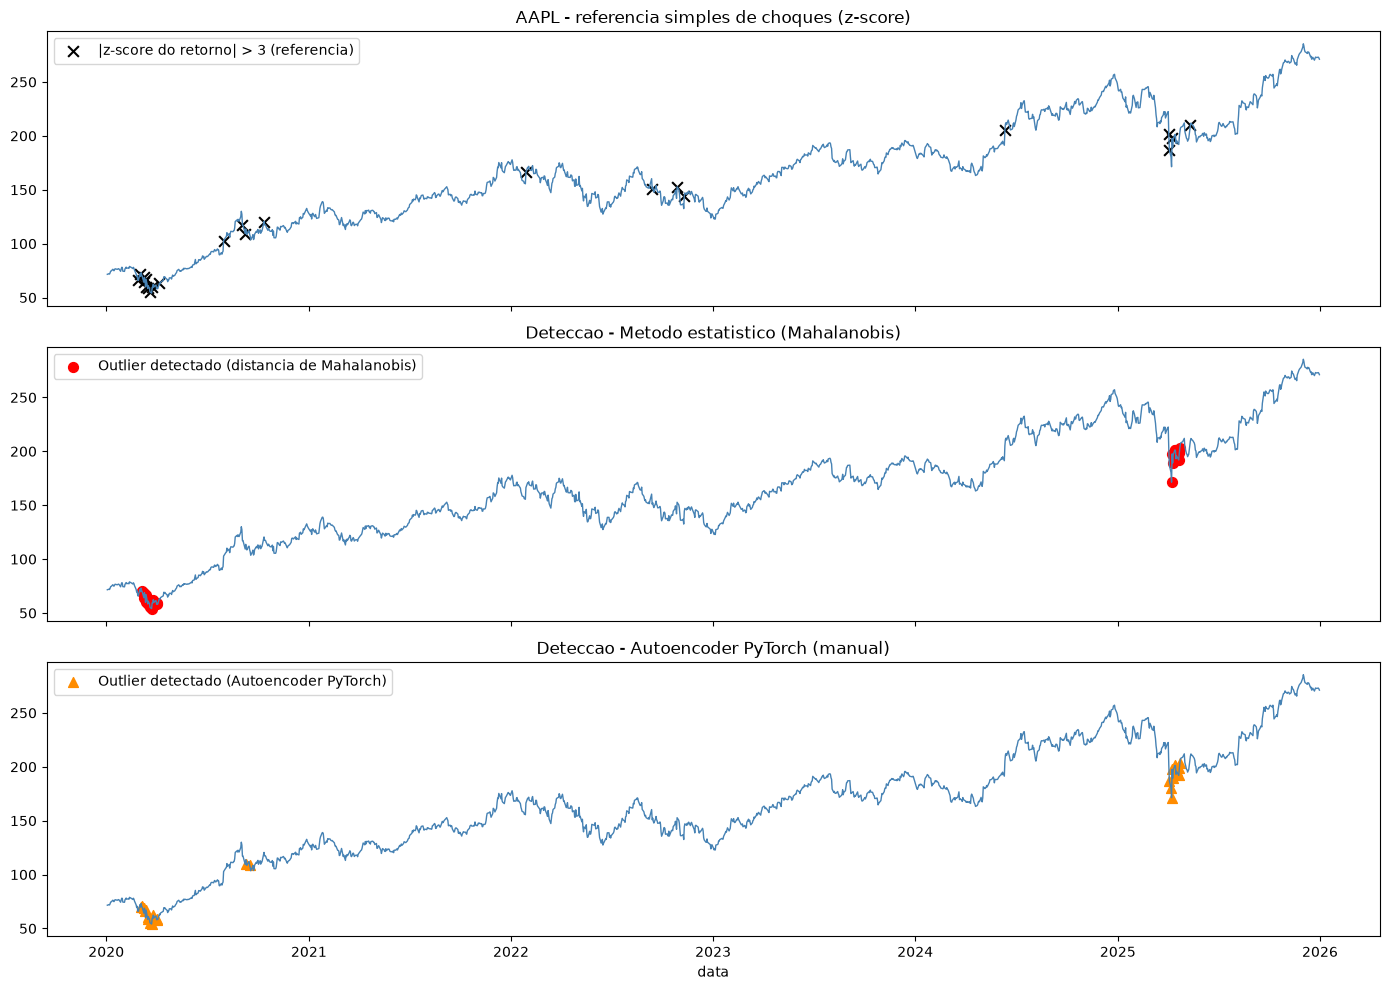

In [35]:
figure, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df["date"], df["price"], color="steelblue", linewidth=1)
axes[0].scatter(
    df["date"].values[zscore_outlier_indices],
    df["price"].values[zscore_outlier_indices],
    color="black",
    marker="x",
    s=60,
    label="|z-score do retorno| > 3 (referencia)",
)
axes[0].set_title(f"{TICKER} - referencia simples de choques (z-score)")
axes[0].legend()

stat_detected_indices = window_end_indices[stat_labels == 1]
axes[1].plot(df["date"], df["price"], color="steelblue", linewidth=1)
axes[1].scatter(
    df["date"].values[stat_detected_indices],
    df["price"].values[stat_detected_indices],
    color="red",
    marker="o",
    s=50,
    label="Outlier detectado (distancia de Mahalanobis)",
)
axes[1].set_title("Deteccao - Metodo estatistico (Mahalanobis)")
axes[1].legend()

torch_detected_indices = window_end_indices[torch_labels == 1]
axes[2].plot(df["date"], df["price"], color="steelblue", linewidth=1)
axes[2].scatter(
    df["date"].values[torch_detected_indices],
    df["price"].values[torch_detected_indices],
    color="darkorange",
    marker="^",
    s=50,
    label="Outlier detectado (Autoencoder PyTorch)",
)
axes[2].set_title("Deteccao - Autoencoder PyTorch (manual)")
axes[2].legend()
axes[2].set_xlabel("data")

plt.tight_layout()
plt.show()

## Comparação quantitativa entre os métodos

A função `compute_overlap` mede a fração de índices de um conjunto
que estão próximos (dentro de uma tolerância) de algum índice de um
segundo conjunto, permitindo comparar a concordância entre os
métodos.

In [36]:
def compute_overlap(
    reference_indices: np.ndarray,
    comparison_indices: np.ndarray,
    tolerance: int = 2,
) -> float:
    """Compute the fraction of reference indices near comparison indices.

    Args:
        reference_indices: The array of indices to be evaluated.
        comparison_indices: The array of indices to compare against.
        tolerance: The maximum allowed distance, in index positions,
            for two indices to be considered a match.

    Returns:
        The fraction of `reference_indices` that lie within
        `tolerance` steps of at least one value in
        `comparison_indices`. Returns 0.0 if `reference_indices` is
        empty.

    Example:
        >>> compute_overlap(np.array([5, 10]), np.array([6, 20]), 2)
        0.5
    """
    comparison_set = set(comparison_indices)
    if len(reference_indices) == 0:
        return 0.0
    matches = sum(
        any(abs(index - value) <= tolerance for value in comparison_set)
        for index in reference_indices
    )
    return matches / len(reference_indices)

In [37]:
print("=== Sobreposicao entre os metodos (tolerancia de 2 passos) ===")
print(f"Metodo estatistico detectados: {len(stat_detected_indices)}")
print(f"PyTorch detectados:            {len(torch_detected_indices)}")
print(f"z-score (>3) pontos:           {len(zscore_outlier_indices)}")

stat_torch_overlap = compute_overlap(stat_detected_indices, torch_detected_indices)
stat_zscore_overlap = compute_overlap(stat_detected_indices, zscore_outlier_indices)
torch_zscore_overlap = compute_overlap(torch_detected_indices, zscore_outlier_indices)

print(f"Estatistico x PyTorch (overlap): {stat_torch_overlap:.2f}")
print(f"Estatistico x z-score:           {stat_zscore_overlap:.2f}")
print(f"PyTorch x z-score:               {torch_zscore_overlap:.2f}")

=== Sobreposicao entre os metodos (tolerancia de 2 passos) ===
Metodo estatistico detectados: 30
PyTorch detectados:            30
z-score (>3) pontos:           23
Estatistico x PyTorch (overlap): 1.00
Estatistico x z-score:           0.70
PyTorch x z-score:               0.67


## Registro do experimento no wandb

As métricas finais de sobreposição entre os métodos são registradas
no run do wandb, junto com o modelo `SimpleAutoencoder` treinado,
salvo como artifact. Por fim, o run é encerrado.

In [38]:
experiment_tracker.log_metrics(
    {
        "eval/stat_detected_count": len(stat_detected_indices),
        "eval/torch_detected_count": len(torch_detected_indices),
        "eval/zscore_detected_count": len(zscore_outlier_indices),
        "eval/stat_torch_overlap": stat_torch_overlap,
        "eval/stat_zscore_overlap": stat_zscore_overlap,
        "eval/torch_zscore_overlap": torch_zscore_overlap,
    }
)

experiment_tracker.log_model(
    model=torch_model,
    model_name="outlier-detection-autoencoder",
    model_file_path="outlier_autoencoder.pt",
    description="Autoencoder simples para deteccao de outliers em janelas de log-retornos.",
    metadata={
        "final_train_loss": torch_scores.mean().item(),
        "stat_torch_overlap": stat_torch_overlap,
    },
)

experiment_tracker.finish_run()

eval/stat_detected_count: 30 | eval/torch_detected_count: 30 | eval/zscore_detected_count: 23 | eval/stat_torch_overlap: 1.000000 | eval/stat_zscore_overlap: 0.700000 | eval/torch_zscore_overlap: 0.666667
[wandb] Logged model artifact 'outlier-detection-autoencoder' from 'outlier_autoencoder.pt'.


epoch,▁▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
eval/stat_detected_count,▁
eval/stat_torch_overlap,▁
eval/stat_zscore_overlap,▁
eval/torch_detected_count,▁
eval/torch_zscore_overlap,▁
eval/zscore_detected_count,▁
train/loss_mse,█████▇▇▇▇▇▇▇▆▆▆▆▅▄▄▄▃▃▃▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁
epoch,300
eval/stat_detected_count,30
eval/stat_torch_overlap,1


## Distribuição dos escores de anomalia

Por fim, comparam-se as distribuições dos escores de anomalia gerados
pelo método estatístico da distância de Mahalanobis e pelo
autoencoder manual em `PyTorch`.

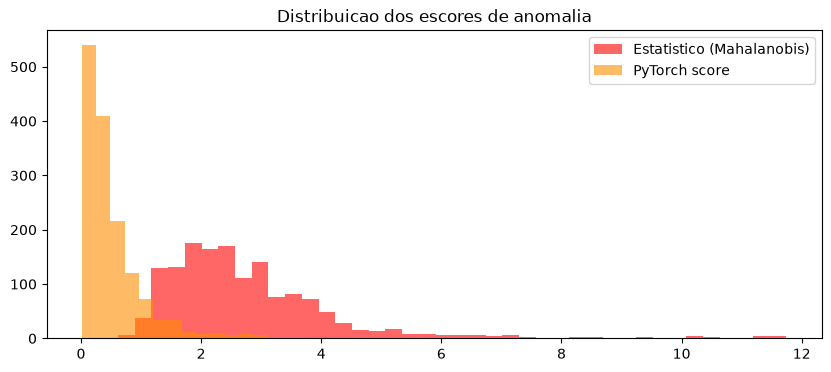

In [39]:
figure, axis = plt.subplots(figsize=(10, 4))
axis.hist(stat_scores, bins=40, alpha=0.6, label="Estatistico (Mahalanobis)", color="red")
axis.hist(torch_scores, bins=40, alpha=0.6, label="PyTorch score", color="darkorange")
axis.set_title("Distribuicao dos escores de anomalia")
axis.legend()
plt.show()